In [3]:
import pickle
import gzip
import lzma, os
import numpy as np
from pathlib import Path
from glob import glob
from tqdm import tqdm
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from typing import Tuple, List, Optional

In [4]:
base_folder = "/datashare/datasets/lead/"
# for scene_folder in os.listdir(base_folder):
#     print(scene_folder)
window_size = 10
dense_route_planner_min_distance = 2.4
num_route_points_smoothing = 10

In [ ]:
all_segments = []  # To store all aggregated segments
    
# Convert to Path object if it's a string
base_path = Path(base_folder)

# Iterate through all scene folders
scene_count = 0
for scene_folder in tqdm(base_path.iterdir()):
    scene_count += 1
    print("processing {}".format(str(scene_folder).split('/')[-1]))
    # if scene_count > 2:
    #     break
    if not scene_folder.is_dir():
        continue
        
    # Iterate through all route folders in the scene folder
    for route_folder in scene_folder.iterdir():
        # Skip if not a directory or ends with .zip
        if not route_folder.is_dir() or str(route_folder).endswith('.zip'):
            continue
        
        # Path to metas folder
        metas_path = route_folder / 'metas'
        
        # Check if metas folder exists
        if not metas_path.exists() or not metas_path.is_dir():
            print(f"Warning: metas folder not found in {route_folder}")
            continue
        
        # Process all pickle files in metas folder
        for pkl_file in metas_path.glob('*.pkl'):
            try:
                # Load the pickle file
                # with open(pkl_file, 'rb') as f:
                #     data = pickle.load(f)
                with lzma.open(pkl_file, "rb") as f:
                    data =  pickle.load(f)
                
                # Extract route and speed
                route = data['route']  # Shape (50, 2)
                speed = data['speed']  # float
                
                # Get first 10 points from route
                segment = route[:10, :]  # Shape (10, 2)
                segment = smooth_path(segment, target_first_distance=2.5)

                # Debug offset
                if segment[0,0] > 5:
                    print(pkl_file)
                
                # Expand speed to (1, 2) with one zero
                speed_expanded = np.array([[speed, 0.0]])  # Shape (1, 2)
                
                # Append speed after the segment
                full_segment = np.vstack([segment, speed_expanded])  # Shape (11, 2)
                
                # Add to the list
                all_segments.append(full_segment.reshape(-1))
                
            except Exception as e:
                print(f"Error processing {pkl_file}: {e}")
                continue

# Convert list of segments to a single numpy array
if all_segments:
    # Result will be of shape (n_segments, 11, 2)
    aggregated_array = np.array(all_segments)

# anchor_dir = '/data/workspace/uis1sgh/VLX_Research/carla_garage/data/lead_anchor/lead_seg_cp_spd_win{}.npz'.format(window_size)
# np.savez_compressed(anchor_dir,segments=aggregated_array)

In [5]:
window_size = 10
anchor_dir = '/data/workspace/uis1sgh/VLX_Research/carla_garage/data/lead_anchor/lead_seg_cp_spd_win{}.npz'.format(window_size)
aggregated_array = np.load(anchor_dir, allow_pickle=True)['segments']
# np.savez_compressed(anchor_dir,segments=aggregated_array)

In [8]:
aggregated_array.shape

(1112085, 22)

Clustering 1112085 trajectory windows into 10 clusters...


Text(0.5, 1.0, 'Least Frequent 10 of 10 Clusters')

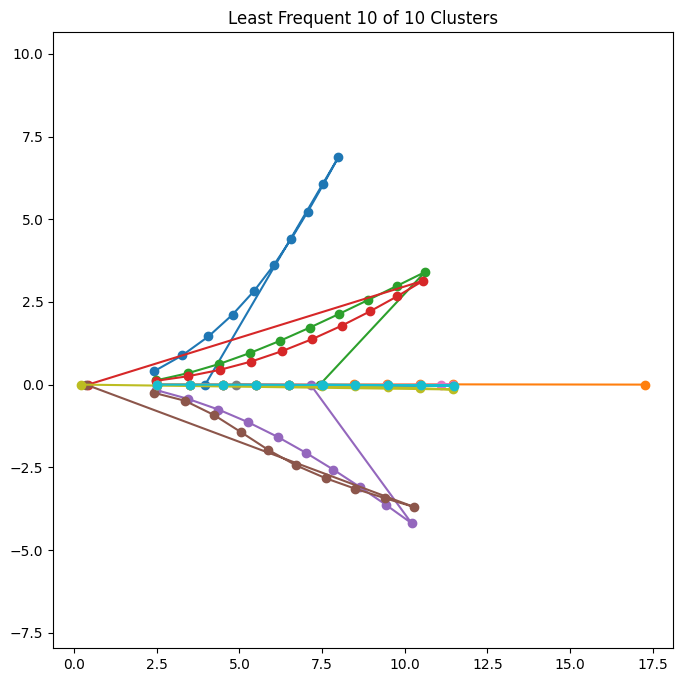

In [7]:
K = 10
keep_top = 10  # Keep least frequent clusters

print(f"Clustering {aggregated_array.shape[0]} trajectory windows into {K} clusters...")
kmeans = KMeans(n_clusters=K, random_state=0).fit(aggregated_array)
labels = kmeans.labels_
counts = np.bincount(labels)

least_common_indices = np.argsort(counts)[:keep_top]  # smallest frequencies
selected_centers = kmeans.cluster_centers_[least_common_indices].reshape(keep_top, window_size+1, 2)

output_anchor = f'/data/workspace/uis1sgh/VLX_Research/bridge_lead/anchor_utils/anchor_data/lead_cp_kmeans_spd_{K}_{window_size}.npy'

np.save(output_anchor, selected_centers)
# print(f"Saved: {output_anchor}")

plt.figure(figsize=(8, 8))
for i, idx in enumerate(least_common_indices):
    center = selected_centers[i]
    plt.plot(center[:, 0], center[:, 1], marker='o', label=f'Cluster {idx}')
plt.axis('equal')
plt.title(f'Least Frequent {keep_top} of {K} Clusters')
# plt.tight_layout()
# plt.savefig(output_anchor.replace('.npy', '.png'))
# plt.close()

In [ ]:
def iterative_line_interpolation(
    route,
    target_first_distance: float):
    """Generate evenly-spaced interpolated points along a route using circle-line intersection.

    This function creates a smoothed route representation by iteratively finding points at
    fixed distances along the input route. It uses a geometric approach where each new point
    is found at the intersection of a circle (centered at the last interpolated point) with
    the line segments of the original route.

    The algorithm:
    1. Places the first point at `target_first_distance` from the origin (0, 0)
    2. Places subsequent points exactly 1.0 meter apart along the route
    3. When multiple intersections exist, selects the one in the forward direction
    4. Extrapolates beyond the route end if needed to reach the target number of points

    Args:
        config: Training configuration containing route planning parameters, specifically:
            - num_route_points_smoothing: Number of interpolated points to generate
            - dense_route_planner_min_distance: Initial minimum distance (unused, overwritten)
        route: Array of shape (N, 2) containing the input waypoints as (x, y) coordinates.
        target_first_distance: Distance in meters for the first interpolated point from origin.

    Returns:
        Array of shape (num_route_points_smoothing, 2) containing evenly-spaced interpolated
        waypoints along the route.

    Raises:
        Exception: If no intersection is found during interpolation (should not occur under
            normal circumstances).
    """
    interpolated_route_points = []

    # this value is actually not used anymore, it is overwritten in the loop
    min_distance = dense_route_planner_min_distance
    last_interpolated_point = np.array([0.0, 0.0])
    current_route_index = 0
    current_point = route[current_route_index]
    last_point = np.array([0.0, 0.0])
    first_iteration = True

    while len(interpolated_route_points) < num_route_points_smoothing:
        # First point should be target_first_distance away from the vehicle.
        if not first_iteration:
            current_route_index += 1
            last_point = current_point

        if current_route_index < route.shape[0]:
            current_point = route[current_route_index]
            intersection = circle_line_segment_intersection(
                circle_center=last_interpolated_point,
                circle_radius=(
                    min_distance if not first_iteration else target_first_distance
                ),
                pt1=last_interpolated_point,
                pt2=current_point,
                full_line=True,
            )

        else:  # We hit the end of the input route. We extrapolate the last 2 points
            current_point = route[-1]
            last_point = route[-2]
            intersection = circle_line_segment_intersection(
                circle_center=last_interpolated_point,
                circle_radius=min_distance,
                pt1=last_point,
                pt2=current_point,
                full_line=True,
            )

        # 3 cases: 0 intersection, 1 intersection, 2 intersection
        if len(intersection) > 1:  # 2 intersections
            # Take the one that is closer to current point
            point_1 = np.array(intersection[0])
            point_2 = np.array(intersection[1])
            direction = current_point - last_point
            dot_p1_to_last = np.dot(point_1, direction)
            dot_p2_to_last = np.dot(point_2, direction)

            if dot_p1_to_last > dot_p2_to_last:
                intersection_point = point_1
            else:
                intersection_point = point_2
            add_point = True
        elif len(intersection) == 1:  # 1 Intersections
            intersection_point = np.array(intersection[0])
            add_point = True
        else:  # 0 Intersection
            add_point = False
            raise Exception("No intersection found. This should never occur.")

        if add_point:
            last_interpolated_point = intersection_point
            interpolated_route_points.append(intersection_point)
            min_distance = 1.0  # After the first point we want each point to be 1 m away from the last.

        first_iteration = False

    interpolated_route_points = np.array(interpolated_route_points)
    return interpolated_route_points

def circle_line_segment_intersection(
    circle_center: np.ndarray,  # Shape: (2,)
    circle_radius: float,
    pt1: np.ndarray,            # Shape: (2,)
    pt2: np.ndarray,            # Shape: (2,)
    full_line: bool = True,
    tangent_tol: float = 1e-9,
) -> List[tuple[float, float]]:
    """Find the intersection points between a circle and a line segment.

    Computes geometric intersections using the analytical solution for circle-line
    intersection. The function can return 0, 1, or 2 intersection points depending
    on whether the line misses, is tangent to, or crosses through the circle.

    Args:
        circle_center: The (x, y) coordinates of the circle center.
        circle_radius: The radius of the circle.
        pt1: The (x, y) coordinates of the first point of the line segment.
        pt2: The (x, y) coordinates of the second point of the line segment.
        full_line: If True, find intersections along the infinite line extending through
            pt1 and pt2. If False, only return intersections within the segment [pt1, pt2].
        tangent_tol: Numerical tolerance for determining if the line is tangent to the circle.
            When discriminant is below this threshold, treat as tangent case.

    Returns:
        A list of (x, y) tuples representing intersection points. The list contains:
        - 0 elements if no intersection exists
        - 1 element if the line is tangent to the circle
        - 2 elements if the line crosses through the circle
        Points are ordered along the direction from pt1 to pt2.

    Note:
        Implementation follows the analytical solution from:
        http://mathworld.wolfram.com/Circle-LineIntersection.html
        Credit: https://stackoverflow.com/a/59582674/9173068
    """
    # if np.linalg.norm(pt1 - pt2) < 0.000000001:
    #     LOG.warning("Problem")

    (p1x, p1y), (p2x, p2y), (cx, cy) = pt1, pt2, circle_center
    (x1, y1), (x2, y2) = (p1x - cx, p1y - cy), (p2x - cx, p2y - cy)
    dx, dy = (x2 - x1), (y2 - y1)
    dr = (dx**2 + dy**2) ** 0.5
    big_d = x1 * y2 - x2 * y1
    discriminant = circle_radius**2 * dr**2 - big_d**2

    if discriminant < 0:  # No intersection between circle and line
        return []
    else:  # There may be 0, 1, or 2 intersections with the segment
        # This makes sure the order along the segment is correct
        intersections = [
            (
                cx
                + (big_d * dy + sign * (-1 if dy < 0 else 1) * dx * discriminant**0.5)
                / dr**2,
                cy + (-big_d * dx + sign * abs(dy) * discriminant**0.5) / dr**2,
            )
            for sign in ((1, -1) if dy < 0 else (-1, 1))
        ]
        if not full_line:  # If only considering the segment, filter out intersections that do not fall within the segment
            fraction_along_segment = [
                (xi - p1x) / dx if abs(dx) > abs(dy) else (yi - p1y) / dy
                for xi, yi in intersections
            ]
            intersections = [
                pt
                for pt, frac in zip(intersections, fraction_along_segment, strict=False)
                if 0 <= frac <= 1
            ]
        # If line is tangent to circle, return just one point (as both intersections have same location)
        if len(intersections) == 2 and abs(discriminant) <= tangent_tol:
            return [intersections[0]]
        else:
            return intersections

def smooth_path(
    route,
    target_first_distance: float,
):
    """Smooth a route by removing duplicates and creating evenly-spaced interpolated waypoints.

    This function preprocesses a route by removing duplicate waypoints while preserving the
    original path order, then generates a smoothed representation with evenly-spaced points
    using iterative line interpolation.

    The smoothing process:
    1. Identifies and removes duplicate consecutive waypoints
    2. Preserves the original route order (important for path following)
    3. Generates interpolated points at regular intervals along the cleaned route

    Args:
        config: Training configuration containing route smoothing parameters such as
            the number of interpolated points to generate.
        route: Array of shape (N, 2) containing input waypoints as (x, y) coordinates.
            May contain duplicate points.
        target_first_distance: Distance in meters for placing the first interpolated point
            from the origin (0, 0).

    Returns:
        Array of shape (num_route_points_smoothing, 2) containing the smoothed route
        with evenly-spaced waypoints. All duplicates are removed and spacing is regularized.
    """
    _, indices = np.unique(route, return_index=True, axis=0)
    # We need to remove the sorting of unique, because this algorithm assumes the order of the path is kept
    route = np.array(route)
    indices = np.sort(indices)
    indices = np.array(indices).astype(int)
    route = route[indices]
    interpolated_route_points = iterative_line_interpolation(route, target_first_distance)

    return interpolated_route_points